In [2]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from keras import layers, models
from keras.optimizers import Adam
from keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, ModelCheckpoint

In [3]:
path = "dataset"

print("Path to dataset files:", path)

Path to dataset files: dataset


In [ ]:
# Paths and configs

DATA_DIR = path

MODEL_PATH = "models/ingredient_model.keras"
MODEL_PATH_ = "models/ingredient_model.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCH = 30

In [5]:
# Datagen preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,         
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Add validation and test datagen
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR + "/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    DATA_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.


In [6]:
# print class names
if os.path.isdir(DATA_DIR + "/train"):
    CLASS_NAMES = sorted(os.listdir(DATA_DIR + "/train"))

print(CLASS_NAMES)

['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [7]:
# Model compilation
base_model = MobileNetV2(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False  # freeze for fast training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

2025-12-12 13:21:42.218197: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
# add earlystoping callbacks
Callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.25, patience=3, verbose=1)
]

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,172 (9.90 MB)

 Trainable params: 337,188 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
# train top layers only
print("Training started...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    callbacks=Callbacks
)


Training started...
Epoch 1/30
125/779 ━━━━━━━━━━━━━━━━━━━━ 3:43 342ms/step - accuracy: 0.1891 - loss: 3.4953

/home/wills/.local/lib/python3.12/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


779/779 ━━━━━━━━━━━━━━━━━━━━ 298s 369ms/step - accuracy: 0.5579 - loss: 1.5829 - val_accuracy: 0.8319 - val_loss: 0.4859 - learning_rate: 0.0010
Epoch 2/30
779/779 ━━━━━━━━━━━━━━━━━━━━ 282s 361ms/step - accuracy: 0.7159 - loss: 0.8992 - val_accuracy: 0.8860 - val_loss: 0.3386 - learning_rate: 0.0010
Epoch 3/30
779/779 ━━━━━━━━━━━━━━━━━━━━ 362s 464ms/step - accuracy: 0.7544 - loss: 0.7432 - val_accuracy: 0.9060 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 4/30
779/779 ━━━━━━━━━━━━━━━━━━━━ 255s 325ms/step - accuracy: 0.7859 - loss: 0.6609 - val_accuracy: 0.9174 - val_loss: 0.2943 - learning_rate: 0.0010
Epoch 5/30
779/779 ━━━━━━━━━━━━━━━━━━━━ 380s 478ms/step - accuracy: 0.8093 - loss: 0.5656 - val_accuracy: 0.8917 - val_loss: 0.2882 - learning_rate: 0.0010
Epoch 6/30
779/779 ━━━━━━━━━━━━━━━━━━━━ 347s 444ms/step - accuracy: 0.8250 - loss: 0.5162 - val_accuracy: 0.9145 - val_loss: 0.3013 - learning_rate: 0.0010
Epoch 7/30
779/779 ━━━━━━━━━━━━━━━━━━━━ 335s 384ms/step - accuracy: 0.8299 

In [72]:
# save model
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH)
print(f"Model saved TO {MODEL_PATH}")

# Also save in '.h5' format
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH_)
print(f"Model saved TO {MODEL_PATH_}")

Model saved TO models/ingredient_model.keras
Model saved TO models/ingredient_model.h5


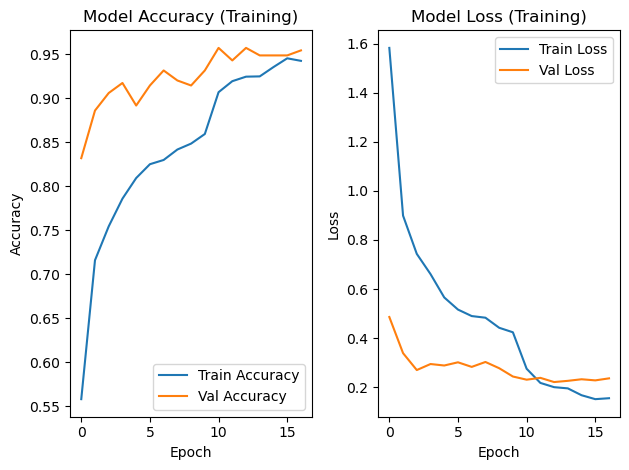

In [32]:
# Plot training history

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Model Accuracy (Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Model Loss (Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
 
plt.tight_layout()
plt.show()

In [66]:
# Evaluation on test set.
print("Evaluating on unseen test set...")

test_loss, test_accuracy = model.evaluate(test_gen, verbose=1)
print(f"\nTest accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest loss: {test_loss:.4f}")


Evaluating on unseen test set...
90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 324ms/step - accuracy: 0.9582 - loss: 0.2266

Test accuracy: 0.9582 (95.82%)

Test loss: 0.2266


In [67]:
# Take one batch from test set
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


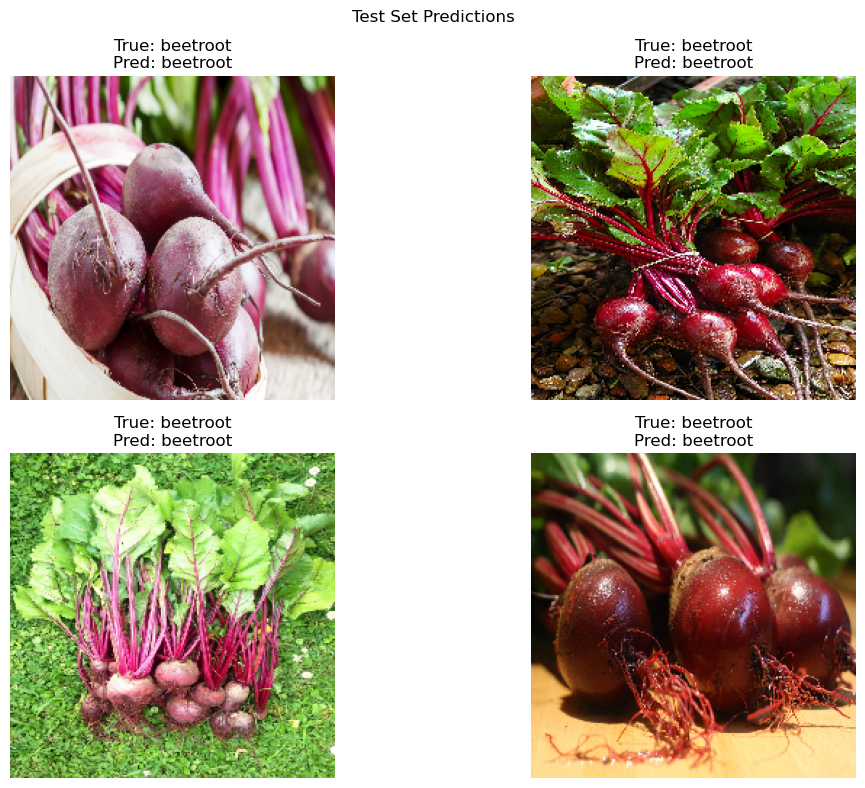

In [ ]:
# Show first 6 predictions
plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 2, i+1)
    plt.imshow(test_images[i])
    plt.title(f"True: {CLASS_NAMES[true_classes[i]]}\nPred: {CLASS_NAMES[pred_classes[i]]}")
    plt.axis('off')
plt.suptitle("Test Set Predictions")
plt.tight_layout()
plt.show()